# Reading data in-depth

# 1. Reading data from CSV, TSV

In [3]:
import pandas as pd

## CSV, TSV and TXT can be read from pd.read_csv
### Documentation can be found via pandas' online documentation 
https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html

### or inside python below

In [2]:
pd.read_csv?

Signature:
pd.read_csv(
    filepath_or_buffer: 'FilePath | ReadCsvBuffer[bytes] | ReadCsvBuffer[str]',
    *,
    sep: 'str | None | lib.NoDefault' = <no_default>,
    delimiter: 'str | None | lib.NoDefault' = None,
    header: "int | Sequence[int] | None | Literal['infer']" = 'infer',
    names: 'Sequence[Hashable] | None | lib.NoDefault' = <no_default>,
    index_col: 'IndexLabel | Literal[False] | None' = None,
    usecols: 'UsecolsArgType' = None,
    dtype: 'DtypeArg | None' = None,
    engine: 'CSVEngine | None' = None,
    converters: 'Mapping[Hashable, Callable] | None' = None,
    true_values: 'list | None' = None,
    false_values: 'list | None' = None,
    skipinitialspace: 'bool' = False,
    skiprows: 'list[int] | int | Callable[[Hashable], bool] | None' = None,
    skipfooter: 'int' = 0,
    nrows: 'int | None' = None,
    na_values: 'Hashable | Iterable[Hashable] | Mapping[Hashable, Iterable[Hashable]] | None' = None,
    keep_default_na: 'bool' = True,
    na_filter: '

## Reading simple CSV, all parameters will be set to default, hence only specify where is CSV file is stored, the rest will be done by Pandas

In [3]:
simple_csv = pd.read_csv('data/test_data/simple.csv')

In [4]:
simple_csv.head()

,usertype,gender_label,number_trips,trip_duration_hours,avg_trip_duration_hours,number_bikes_used,avg_age_users
0,Customer,Female,4090,3014.996111,0.737163,3147,29.193154
1,Customer,Male,6130,4946.235000,0.806890,4245,29.846166
2,Customer,Unknown,7494,4781.653333,0.638064,5208,50.587937
3,Subscriber,Female,18607,5718.467500,0.307329,8217,36.988069
4,Subscriber,Male,39209,10413.190000,0.265582,10365,38.321967


## Thing becomes a bit complex when data is read from report file with headers and footers or data is stored in a specific location of the file

In [5]:
pd.read_csv('data/test_data/csv_header_footer.csv')

,trip report,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,date: 2019/09/30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,usertype,gender_label,number_trips,trip_duration_hours,avg_trip_duration_hours,number_bikes_used,avg_age_users
3,NaN,Customer,Female,4090,3014.996111,0.737162863,3147,29.19315403
4,NaN,Customer,Male,6130,4946.235,0.806889886,4245,29.84616639
5,NaN,Customer,Unknown,7494,4781.653333,0.638064229,5208,50.58793702
6,NaN,Subscriber,Female,18607,5718.4675,0.307328828,8217,36.98806901
7,NaN,Subscriber,Male,39209,10413.19,0.265581627,10365,38.3219669
8,NaN,Subscriber,Unknown,1145,282.9588889,0.247125667,971,44.73275109
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## It assumes first row as column header and below it as structured data

### As column headers are at 3rd row, the data is started from column #2

In [13]:
pd.read_csv('data/test_data/csv_header_footer.csv', 
            skiprows=[0,1,2], 
            usecols=['usertype', 'gender_label', 'number_trips', 'trip_duration_hours', 'avg_trip_duration_hours', 'number_bikes_used', 'avg_age_users'],
            skipfooter=6
           )

C:\Users\admin\AppData\Local\Temp\ipykernel_21604\1871672404.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  pd.read_csv('data/test_data/csv_header_footer.csv',


,usertype,gender_label,number_trips,trip_duration_hours,avg_trip_duration_hours,number_bikes_used,avg_age_users
0,Customer,Female,4090,3014.996111,0.737163,3147,29.193154
1,Customer,Male,6130,4946.235000,0.806890,4245,29.846166
2,Customer,Unknown,7494,4781.653333,0.638064,5208,50.587937
3,Subscriber,Female,18607,5718.467500,0.307329,8217,36.988069
4,Subscriber,Male,39209,10413.190000,0.265582,10365,38.321967
5,Subscriber,Unknown,1145,282.958889,0.247126,971,44.732751


## Read TSV
### The difference between CSV and TSV is basically the use of separators in the dataset. CSV uses "," while TSV use "TAB".
### In Pandas, the data reading module is the same, the difference is on the specification of "sep".
## This can be generalised to reading any structured data from plain text. You just need to specify separator.

In [15]:
pd.read_csv('data/201909_citybike/tsv/citibike_20-09-01.txt', sep='\t')

,tripduration,starttime,stoptime,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station latitude,end station longitude,bikeid,usertype,birth year,gender
0,4225,2020-09-01 00:00:01.043,2020-09-01 01:10:26.635,3508,St Nicholas Ave & Manhattan Ave,40.809725,-73.953149,116,W 17 St & 8 Ave,40.741776,-74.001497,44317,Customer,1979,1
1,1868,2020-09-01 00:00:04.832,2020-09-01 00:31:13.765,3621,27 Ave & 9 St,40.773983,-73.930913,3094,Graham Ave & Withers St,40.716981,-73.944859,37793,Customer,1991,1
2,1097,2020-09-01 00:00:06.899,2020-09-01 00:18:24.226,3492,E 118 St & Park Ave,40.800539,-73.941995,3959,Edgecombe Ave & W 145 St,40.823498,-73.943860,41438,Subscriber,1984,1
3,1473,2020-09-01 00:00:07.744,2020-09-01 00:24:41.180,3946,St Nicholas Ave & W 137 St,40.818477,-73.947568,4002,W 144 St & Adam Clayton Powell Blvd,40.820877,-73.939249,35860,Customer,1990,2
4,1193,2020-09-01 00:00:12.202,2020-09-01 00:20:05.547,3081,Graham Ave & Grand St,40.711863,-73.944024,3048,Putnam Ave & Nostrand Ave,40.684020,-73.949770,26396,Customer,1969,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76669,3676,2020-09-01 23:59:40.352,2020-09-02 01:00:56.568,482,W 15 St & 7 Ave,40.739355,-73.999318,212,W 16 St & The High Line,40.743349,-74.006818,42032,Customer,1969,0
76670,720,2020-09-01 23:59:40.456,2020-09-02 00:11:40.974,3358,Garfield Pl & 8 Ave,40.671198,-73.974841,3048,Putnam Ave & Nostrand Ave,40.684020,-73.949770,38044,Subscriber,1980,1
76671,639,2020-09-01 23:59:43.659,2020-09-02 00:10:23.532,468,Broadway & W 56 St,40.765265,-73.981923,3177,W 84 St & Broadway,40.786795,-73.977112,37287,Subscriber,1961,1
76672,434,2020-09-01 23:59:52.633,2020-09-02 00:07:07.474,120,Lexington Ave & Classon Ave,40.686768,-73.959282,3549,Grand Ave & Bergen St,40.678045,-73.962408,41358,Subscriber,1974,1


# Common used sparators
* ,
* \t
* |
* ||
* ;

## Reading data from multiple files
## a. Get list of the files
## b. Loop to read those files and store them in list
## c. Combine those data together

In [2]:
import glob

In [19]:
FILE_LIST = glob.glob('data/201909_citybike/csv/*.csv')
FILE_LIST

['data/201909_citybike/csv\\citybike_20-09-01.csv',
 'data/201909_citybike/csv\\citybike_20-09-02.csv',
 'data/201909_citybike/csv\\citybike_20-09-03.csv',
 'data/201909_citybike/csv\\citybike_20-09-04.csv',
 'data/201909_citybike/csv\\citybike_20-09-05.csv',
 'data/201909_citybike/csv\\citybike_20-09-06.csv',
 'data/201909_citybike/csv\\citybike_20-09-07.csv',
 'data/201909_citybike/csv\\citybike_20-09-08.csv',
 'data/201909_citybike/csv\\citybike_20-09-09.csv',
 'data/201909_citybike/csv\\citybike_20-09-10.csv',
 'data/201909_citybike/csv\\citybike_20-09-11.csv',
 'data/201909_citybike/csv\\citybike_20-09-12.csv',
 'data/201909_citybike/csv\\citybike_20-09-13.csv',
 'data/201909_citybike/csv\\citybike_20-09-14.csv',
 'data/201909_citybike/csv\\citybike_20-09-15.csv',
 'data/201909_citybike/csv\\citybike_20-09-16.csv',
 'data/201909_citybike/csv\\citybike_20-09-17.csv',
 'data/201909_citybike/csv\\citybike_20-09-18.csv',
 'data/201909_citybike/csv\\citybike_20-09-19.csv',
 'data/20190

In [20]:
ls = []
for file in FILE_LIST:
    df = pd.read_csv(file)
    ls.append(df)

In [21]:
pd.concat(ls, axis=0)

,tripduration,starttime,stoptime,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station latitude,end station longitude,bikeid,usertype,birth year,gender
0,4225,2020-09-01 00:00:01.0430,2020-09-01 01:10:26.6350,3508,St Nicholas Ave & Manhattan Ave,40.809725,-73.953149,116,W 17 St & 8 Ave,40.741776,-74.001497,44317,Customer,1979,1
1,1868,2020-09-01 00:00:04.8320,2020-09-01 00:31:13.7650,3621,27 Ave & 9 St,40.773983,-73.930913,3094,Graham Ave & Withers St,40.716981,-73.944859,37793,Customer,1991,1
2,1097,2020-09-01 00:00:06.8990,2020-09-01 00:18:24.2260,3492,E 118 St & Park Ave,40.800539,-73.941995,3959,Edgecombe Ave & W 145 St,40.823498,-73.943860,41438,Subscriber,1984,1
3,1473,2020-09-01 00:00:07.7440,2020-09-01 00:24:41.1800,3946,St Nicholas Ave & W 137 St,40.818477,-73.947568,4002,W 144 St & Adam Clayton Powell Blvd,40.820877,-73.939249,35860,Customer,1990,2
4,1193,2020-09-01 00:00:12.2020,2020-09-01 00:20:05.5470,3081,Graham Ave & Grand St,40.711863,-73.944024,3048,Putnam Ave & Nostrand Ave,40.684020,-73.949770,26396,Customer,1969,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85786,1818,2020-09-30 23:59:48.8460,2020-10-01 00:30:07.7810,284,Greenwich Ave & 8 Ave,40.739017,-74.002638,3836,Bushwick Ave & Linden St,40.691460,-73.921460,36220,Subscriber,1993,1
85787,1553,2020-09-30 23:59:53.7240,2020-10-01 00:25:47.1760,390,Duffield St & Willoughby St,40.692216,-73.984284,3799,6 Ave & W 34 St,40.749640,-73.988050,31092,Subscriber,1995,1
85788,626,2020-09-30 23:59:54.6670,2020-10-01 00:10:21.6050,3901,Stanhope St & Fairview Ave,40.709980,-73.911160,3083,Bushwick Ave & Powers St,40.712477,-73.941000,47224,Subscriber,1954,2
85789,325,2020-09-30 23:59:56.2120,2020-10-01 00:05:21.3060,3148,E 84 St & 1 Ave,40.775655,-73.950686,3338,2 Ave & E 99 St,40.786259,-73.945526,16759,Subscriber,1995,2


## Read Large Data in chucks
### It is a generator. Meaning, the data can only read once

In [4]:
large_csv = pd.read_csv('data/2019_citibike-tripdata/combined2.csv', chunksize=1_000_000)

### Choose first chunk as the sample for developing data processing.

In [5]:
first_chunk_csv = next(large_csv)

In [6]:
first_chunk_csv.head()

,tripduration,starttime,stoptime,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station latitude,end station longitude,bikeid,usertype,birth year,gender
0,320,2019-01-01 00:01:47.4010,2019-01-01 00:07:07.5810,3160.0,Central Park West & W 76 St,40.778968,-73.973747,3283.0,W 89 St & Columbus Ave,40.788221,-73.970416,15839,Subscriber,1971,1
1,316,2019-01-01 00:04:43.7360,2019-01-01 00:10:00.6080,519.0,Pershing Square North,40.751873,-73.977706,518.0,E 39 St & 2 Ave,40.747804,-73.973442,32723,Subscriber,1964,1
2,591,2019-01-01 00:06:03.9970,2019-01-01 00:15:55.4380,3171.0,Amsterdam Ave & W 82 St,40.785247,-73.976673,3154.0,E 77 St & 3 Ave,40.773142,-73.958562,27451,Subscriber,1987,1
3,2719,2019-01-01 00:07:03.5450,2019-01-01 00:52:22.6500,504.0,1 Ave & E 16 St,40.732219,-73.981656,3709.0,W 15 St & 6 Ave,40.738046,-73.996430,21579,Subscriber,1990,1
4,303,2019-01-01 00:07:35.9450,2019-01-01 00:12:39.5020,229.0,Great Jones St,40.727434,-73.993790,503.0,E 20 St & Park Ave,40.738274,-73.987520,35379,Subscriber,1979,1


In [7]:
first_chunk_csv.dtypes

tripduration                 int64
starttime                   object
stoptime                    object
start station id           float64
start station name          object
start station latitude     float64
start station longitude    float64
end station id             float64
end station name            object
end station latitude       float64
end station longitude      float64
bikeid                       int64
usertype                    object
birth year                   int64
gender                       int64
dtype: object

In [10]:
first_chunk_csv.tripduration = first_chunk_csv.tripduration.astype(float)
first_chunk_csv.starttime = pd.to_datetime(first_chunk_csv.starttime)
first_chunk_csv.stoptime = pd.to_datetime(first_chunk_csv.stoptime)

## Re-read the data once again to get all chunks

In [14]:
large_csv = pd.read_csv('data/2019_citibike-tripdata/combined2.csv', chunksize=1_000_000)

In [15]:
n = 1
for chunk in large_csv:
    # process data for each chunk
    chunk.tripduration = chunk.tripduration.astype(float)
    chunk.starttime = pd.to_datetime(chunk.starttime)
    chunk.stoptime = pd.to_datetime(chunk.stoptime)
    # produce result
    print(n, chunk.shape)
    n += 1

1 (1000000, 15)
2 (1000000, 15)
3 (1000000, 15)
4 (1000000, 15)
5 (1000000, 15)
6 (1000000, 15)
7 (1000000, 15)
8 (1000000, 15)
9 (1000000, 15)
10 (1000000, 15)
11 (1000000, 15)
12 (1000000, 15)
13 (1000000, 15)
14 (1000000, 15)
15 (1000000, 15)
16 (1000000, 15)
17 (1000000, 15)
18 (1000000, 15)
19 (1000000, 15)
20 (1000000, 15)
21 (551697, 15)


# 2. Reading Data from Excel

## pd.read_excel
* we need to have openpyxl engine installed for reading XLS or XLSX
* We need to have pyxlsb engine installed for reading Excel Binary
* We need to specify sheet name, otherwise the first sheet will be selected
* We can read multiple files the same as reading from plain text
* There is no reading in chunk because Excel has a limited number of rows (1,048,576 rows) and columns (XFD). Plain text literally has not limit for both rows and columns

In [18]:
pd.read_excel('data/201909_citybike/excel/citibike_20-09-01.xlsx', sheet_name='Sheet1', engine='openpyxl')

,tripduration,starttime,stoptime,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station latitude,end station longitude,bikeid,usertype,birth year,gender
0,4225,2020-09-01 00:00:01.043,2020-09-01 01:10:26.635,3508,St Nicholas Ave & Manhattan Ave,40.809725,-73.953149,116,W 17 St & 8 Ave,40.741776,-74.001497,44317,Customer,1979,1
1,1868,2020-09-01 00:00:04.832,2020-09-01 00:31:13.765,3621,27 Ave & 9 St,40.773983,-73.930913,3094,Graham Ave & Withers St,40.716981,-73.944859,37793,Customer,1991,1
2,1097,2020-09-01 00:00:06.899,2020-09-01 00:18:24.226,3492,E 118 St & Park Ave,40.800539,-73.941995,3959,Edgecombe Ave & W 145 St,40.823498,-73.943860,41438,Subscriber,1984,1
3,1473,2020-09-01 00:00:07.744,2020-09-01 00:24:41.180,3946,St Nicholas Ave & W 137 St,40.818477,-73.947568,4002,W 144 St & Adam Clayton Powell Blvd,40.820877,-73.939249,35860,Customer,1990,2
4,1193,2020-09-01 00:00:12.202,2020-09-01 00:20:05.547,3081,Graham Ave & Grand St,40.711863,-73.944024,3048,Putnam Ave & Nostrand Ave,40.684020,-73.949770,26396,Customer,1969,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76669,3676,2020-09-01 23:59:40.352,2020-09-02 01:00:56.568,482,W 15 St & 7 Ave,40.739355,-73.999318,212,W 16 St & The High Line,40.743349,-74.006818,42032,Customer,1969,0
76670,720,2020-09-01 23:59:40.456,2020-09-02 00:11:40.974,3358,Garfield Pl & 8 Ave,40.671198,-73.974841,3048,Putnam Ave & Nostrand Ave,40.684020,-73.949770,38044,Subscriber,1980,1
76671,639,2020-09-01 23:59:43.659,2020-09-02 00:10:23.532,468,Broadway & W 56 St,40.765265,-73.981923,3177,W 84 St & Broadway,40.786795,-73.977112,37287,Subscriber,1961,1
76672,434,2020-09-01 23:59:52.633,2020-09-02 00:07:07.474,120,Lexington Ave & Classon Ave,40.686768,-73.959282,3549,Grand Ave & Bergen St,40.678045,-73.962408,41358,Subscriber,1974,1


# 3. Reading from Parquet file

### Parquet is a very fast columnar data file that comes with compression and encoded schema
### This file format is popular for data file storage
### It is used as file system of Data Lakehouse of Delta Lake

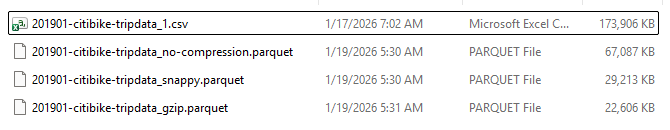

In [20]:
%%timeit
pd.read_csv('data/201909_citybike/parquet/compare_csv/201901-citibike-tripdata_1.csv')

6.6 s ± 521 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [26]:
%%timeit
pd.read_parquet('data/201909_citybike/parquet/compare_csv/201901-citibike-tripdata_no-compression.parquet', engine='pyarrow')

1.54 s ± 76.9 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [27]:
%%timeit
pd.read_parquet('data/201909_citybike/parquet/compare_csv/201901-citibike-tripdata_snappy.parquet', engine='pyarrow')

1.51 s ± 38.8 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [28]:
%%timeit
pd.read_parquet('data/201909_citybike/parquet/compare_csv/201901-citibike-tripdata_gzip.parquet', engine='pyarrow')

1.64 s ± 22.8 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [29]:
6.6/1.51

4.370860927152318

In [25]:
pd.read_parquet?

Signature:
pd.read_parquet(
    path: 'FilePath | ReadBuffer[bytes]',
    engine: 'str' = 'auto',
    columns: 'list[str] | None' = None,
    storage_options: 'StorageOptions | None' = None,
    use_nullable_dtypes: 'bool | lib.NoDefault' = <no_default>,
    dtype_backend: 'DtypeBackend | lib.NoDefault' = <no_default>,
    filesystem: 'Any' = None,
    filters: 'list[tuple] | list[list[tuple]] | None' = None,
    **kwargs,
) -> 'DataFrame'
Docstring:
Load a parquet object from the file path, returning a DataFrame.

Parameters
----------
path : str, path object or file-like object
    String, path object (implementing ``os.PathLike[str]``), or file-like
    object implementing a binary ``read()`` function.
    The string could be a URL. Valid URL schemes include http, ftp, s3,
    gs, and file. For file URLs, a host is expected. A local file could be:
    ``file://localhost/path/to/table.parquet``.
    A file URL can also be a path to a directory that contains multiple
    partitioned p

## Read multiple files are the same as we did for CSV

# 4. Reading from JSON

## From JSON Array

In [40]:
pd.read_json('data/json_us_recipes/population_data.json', orient='records')

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017
0,Aruba,ABW,"Population, total",SP.POP.TOTL,54211.0,55438.0,56225.0,56695.0,57032.0,57360.0,...,101353.0,101453.0,101669.0,102053.0,102577.0,103187.0,103795.0,104341.0,104822.0,105264.0
1,Afghanistan,AFG,"Population, total",SP.POP.TOTL,8996351.0,9166764.0,9345868.0,9533954.0,9731361.0,9938414.0,...,27294031.0,28004331.0,28803167.0,29708599.0,30696958.0,31731688.0,32758020.0,33736494.0,34656032.0,35530081.0
2,Angola,AGO,"Population, total",SP.POP.TOTL,5643182.0,5753024.0,5866061.0,5980417.0,6093321.0,6203299.0,...,21759420.0,22549547.0,23369131.0,24218565.0,25096150.0,25998340.0,26920466.0,27859305.0,28813463.0,29784193.0
3,Albania,ALB,"Population, total",SP.POP.TOTL,1608800.0,1659800.0,1711319.0,1762621.0,1814135.0,1864791.0,...,2947314.0,2927519.0,2913021.0,2905195.0,2900401.0,2895092.0,2889104.0,2880703.0,2876101.0,2873457.0
4,Andorra,AND,"Population, total",SP.POP.TOTL,13411.0,14375.0,15370.0,16412.0,17469.0,18549.0,...,83861.0,84462.0,84449.0,83751.0,82431.0,80788.0,79223.0,78014.0,77281.0,76965.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259,Kosovo,XKX,"Population, total",SP.POP.TOTL,947000.0,966000.0,994000.0,1022000.0,1050000.0,1078000.0,...,1747383.0,1761474.0,1775680.0,1791000.0,1805200.0,1824100.0,1821800.0,1801800.0,1816200.0,1830700.0
260,"Yemen, Rep.",YEM,"Population, total",SP.POP.TOTL,5172135.0,5260501.0,5351799.0,5446063.0,5543339.0,5643643.0,...,22356391.0,22974929.0,23606779.0,24252206.0,24909969.0,25576322.0,26246327.0,26916207.0,27584213.0,28250420.0
261,South Africa,ZAF,"Population, total",SP.POP.TOTL,17456855.0,17920673.0,18401608.0,18899275.0,19412975.0,19942303.0,...,50412129.0,50970818.0,51584663.0,52263516.0,52998213.0,53767396.0,54539571.0,55291225.0,56015473.0,56717156.0
262,Zambia,ZMB,"Population, total",SP.POP.TOTL,3044846.0,3140264.0,3240587.0,3345145.0,3452942.0,3563407.0,...,13082517.0,13456417.0,13850033.0,14264756.0,14699937.0,15153210.0,15620974.0,16100587.0,16591390.0,17094130.0


## From JSON Index

In [39]:
pd.read_json('data/json_us_recipes/US_recipes.json', orient='index')

,Contient,Country_State,cuisine,title,URL,rating,total_time,prep_time,cook_time,description,ingredients,instructions,nutrients,serves
0,North America,US,Southern Recipes,Sweet Potato Pie,https://www.allrecipes.com/recipe/12142/sweet-...,4.8,115.0,15.0,100.0,"Shared from a Southern recipe, this homemade s...","[1 (1 pound) sweet potato, with skin, 0.5 cup ...",[Place whole sweet potato in pot and cover wit...,"{'calories': '389 kcal', 'carbohydrateContent'...",8 servings
1,North America,US,Southern Recipes,Fresh Southern Peach Cobbler,https://www.allrecipes.com/recipe/51535/fresh-...,4.7,60.0,20.0,40.0,This peach cobbler recipe makes the perfect de...,"[8 fresh peaches - peeled, pitted and sliced i...",[Preheat oven to 425 degrees F (220 degrees C)...,"{'calories': '562 kcal', 'carbohydrateContent'...",4 servings
2,North America,US,Southern Recipes,Best Fried Green Tomatoes,https://www.allrecipes.com/recipe/16760/best-f...,4.7,20.0,5.0,15.0,Fried green tomatoes are a quick and easy way ...,"[4 large green tomatoes, 2 eggs, 0.5 cup milk,...",[Slice tomatoes 1/2 inch thick. Discard the en...,"{'calories': '510 kcal', 'carbohydrateContent'...",4 servings
3,North America,US,Southern Recipes,Best Jambalaya,https://www.allrecipes.com/recipe/31848/jambal...,4.8,65.0,20.0,45.0,"A spicy jambalaya with chicken, andouille saus...","[2 tablespoons peanut oil, divided, 1 tablespo...","[Gather all ingredients., Heat 1 tablespoon of...","{'calories': '465 kcal', 'carbohydrateContent'...",6 servings
4,North America,US,Southern Recipes,Authentic Louisiana Red Beans and Rice,https://www.allrecipes.com/recipe/58211/authen...,4.5,690.0,25.0,185.0,This easy authentic Louisiana red beans and ri...,"[1 pound dry kidney beans, 0.25 cup olive oil,...","[Gather all ingredients., Rinse beans, and the...","{'calories': '630 kcal', 'carbohydrateContent'...",8 servings
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8446,North America,US,Amish and Mennonite Recipes,Amish Chocolate Pudding,https://www.allrecipes.com/recipe/278333/amish...,3.3,20.0,5.0,15.0,This Amish grandmother's chocolate pudding rec...,"[2 cups milk, or more as needed, 2 cups white ...","[Combine milk, sugar, cocoa, and flour in a sa...","{'calories': '274 kcal', 'carbohydrateContent'...",8 servings
8447,North America,US,Amish and Mennonite Recipes,Gera's Amish Funny Cake,https://www.allrecipes.com/recipe/139695/geras...,3.6,55.0,25.0,30.0,Amish cooking is amazingly simple and incredib...,"[1 cup white sugar, 0.5 cup cocoa powder, 0.75...",[Preheat oven to 375 degrees F (190 degrees C)...,"{'calories': '343 kcal', 'carbohydrateContent'...",16 servings
8448,North America,US,Amish and Mennonite Recipes,Quick Banana Nut Cake,https://www.allrecipes.com/recipe/232881/quick...,3.0,45.0,15.0,30.0,This Amish banana nut cake is a delightful sna...,"[1 cup white sugar, 0.5 cup butter, 0.25 cup m...",[Preheat oven to 375 degrees F (190 degrees C)...,"{'calories': '273 kcal', 'carbohydrateContent'...",12 servings
8449,North America,US,Amish and Mennonite Recipes,Amish Sour Cream Apple Pie,https://www.allrecipes.com/recipe/278337/amish...,NaN,60.0,15.0,45.0,It doesn't get easier or more delicious than t...,"[1 cup sour cream, 1 egg, 0.75 cup white sugar...",[Preheat the oven to 400 degrees F (200 degree...,"{'calories': '409 kcal', 'carbohydrateContent'...",8 servings
